## Задача 1 (Вариант 1)

Цель: Контроль дисперсии весов.

- Разработать архитектуру, которая будет за 5 слоев приводить тензор к размерности (1, 512, 1, 1).
- Условие: дисперсия весов третьего слоя должна быть в два раза больше, чем у второго и четвертого.
- Эксперимент: Проверить влияние увеличенной дисперсии третьего слоя на распределение активаций после GAP и визуализировать их гистограмму.

### Шаг 1: Импорт библиотек

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.init as init
import torch.nn.functional as F

### Шаг 2: Создание нейросети

In [2]:
class ConvNet(nn.Module):
    def __init__(self):
        
        super().__init__()

        self.layer1 = nn.Conv2d(3, 32, 3, padding=1)    # (32, 32, 32)
        self.layer2 = nn.Conv2d(32, 64, 3, padding=1)   # (64, 32, 32)
        self.layer3 = nn.Conv2d(64, 128, 3, padding=1)  # (128, 32, 32)
        self.layer4 = nn.Conv2d(128, 256, 3, padding=1) # (256, 32, 32)
        self.layer5 = nn.Conv2d(256, 512, 3, padding=1) # (512, 32, 32)

        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):

        # 1
        x = F.relu(self.layer1(x))
        
        # 2
        x = F.relu(self.layer2(x))

        # 3
        x = F.relu(self.layer3(x))

        # 4
        x = F.relu(self.layer4(x))

        # 5
        x = F.relu(self.layer5(x))

        return self.pool(x)



Проверим корректность работы архитектуры

In [3]:
model = ConvNet()
x = torch.randn((1, 3, 32, 32))
y = model(x)
print(y.shape)

torch.Size([1, 512, 1, 1])


### Шаг 3: Создадим функцию инициализации весов

In [4]:
def init_weights(model, default_std=0.1, mean=0.01, multiplier=1):

    for layer in model.modules():

        layer_number = 1

        if isinstance(layer, nn.Conv2d):

            if layer_number != 3:

                std = default_std
                init.normal_(layer.weight, mean, std)
            
            else:

                std = default_std * np.sqrt(multiplier)
                init.normal_(layer.weight, mean, std)

### Шаг 4: Визуализация распределения активаций при разных дисперсиях в 3-м слое с помощью гистограммы

In [5]:
def plot_activation_distributions():

    x = torch.randn(1, 3, 32, 32)
    model_equal_weights, model_nonequal_weights = ConvNet(), ConvNet()
    init_weights(model_equal_weights)
    init_weights(model_nonequal_weights, multiplier=2)
    with torch.no_grad():
        output_equal_weights = model_equal_weights(x)
        output_nonequal_weights = model_nonequal_weights(x)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for i, (data, name) in enumerate([(output_equal_weights, "Равные дисперсии"),
                                      (output_nonequal_weights, "Увеличение дисперсии на 3-м слое")]):
        arr = data.cpu().numpy().flatten()
        axs[i].hist(arr, bins=50)
        axs[i].set_title(f"{name}\nmean={arr.mean():.4f}, std={arr.std():.4f}")

    plt.tight_layout()
    plt.show()

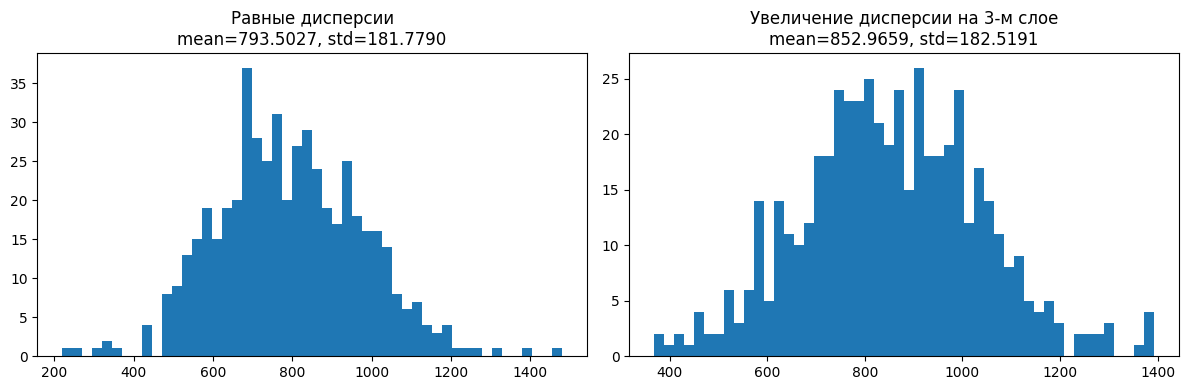

In [6]:
plot_activation_distributions()

При сравнении полученных гистограмм заметно, что увеличение дисперсии на 3-м слое дает также увеличение среднего значения активации.

### Задача 2 (Вариант 6)

Цель: Сравнение MaxPool и Global Average Pooling.

- Спроектировать сеть для входа (3, 64, 64) и выхода (32, 8, 8).
- Условие: В сети обязательно должны быть и MaxPool2d, и AdaptiveAvgPool2d.
- Эксперимент: Сравнить выходы после MaxPool и GAP на одном и том же случайном тензоре, визуализировать карты признаков и среднее значение активаций.

### Шаг 1: Создание нейронной сети

In [7]:
class ConvNetPooling(nn.Module):
    def __init__(self):
        
        super().__init__()

        self.layer1 = nn.Conv2d(3, 16, 3, padding=1)  # (16, 64, 64)
        self.layer2 = nn.Conv2d(16, 32, 3, padding=1) # (32, 64, 64)

        self.maxpool = nn.MaxPool2d(8)     # (32, 8, 8)
        self.GAP = nn.AdaptiveAvgPool2d(8) # (32, 8, 8)

    def forward(self, x):

        # 1
        x = F.relu(self.layer1(x))
        
        # 2
        x = F.relu(self.layer2(x))

        return self.maxpool(x), self.GAP(x)

### Шаг 2: Вычисление среднего значения активации в условиях использования MaxPooling и GAP

In [53]:
x = torch.randn(1, 3, 64, 64)
model = ConvNetPooling()
outs = {
    'MaxPooling': model(x)[0][0].detach().numpy(), 
           'GAP': model(x)[1][0].detach().numpy()
}

abs_diff = np.abs(outs['MaxPooling'] - outs['GAP']) # разность выходов

print(f'Среднее значение выхода MaxPooling: {outs['MaxPooling'].mean()}')
print(f'Среднее значение выхода GAP: {outs['GAP'].mean()}')

Среднее значение выхода MaxPooling: 0.49289265275001526
Среднее значение выхода GAP: 0.11703149974346161


### Шаг 3: Визуалтзация карты признаков и сравнение результатов

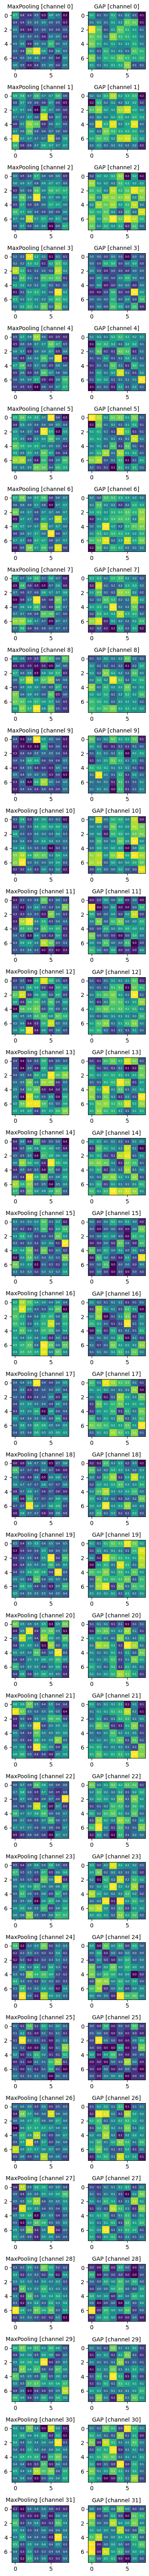

In [72]:
fig, axes = plt.subplots(32, 2, figsize=(4, 64))

for i in range(32):

    for out_name, out in outs.items():

        if out_name == 'MaxPooling':
            ax = axes[i, 0]
        else:
            ax = axes[i, 1]

        ax.imshow(out[i])
        ax.set_title(f'{out_name} [channel {i}]', fontsize=10)

        for k in range(out.shape[1]):

            for m in range(out.shape[2]):
                
                ax.text(m, k, f'{out[i, k, m]:.1f}', 
                        ha='center', va='center',
                        color='white', fontsize=5)

plt.tight_layout()
plt.show()

Среднее значение активаций MaxPool больше, чем GAP. Это объясняется тем, что MaxPool берет максимальное значение из выбранных ячеек, в то время как GAP усредняет их. Эту разницу также можно заметить при сравнении карт признаков - у MaxPool они более светлые, то есть имеет большие значения, чем у GAP.